In [1]:
import json
import requests
import pandas as pd

# Charger les données
base_url = "https://api-base-fastapi-mpt-dkhjb0cydga2aydc.canadacentral-01.azurewebsites.net"
api_key = ""
with open('../api.json', 'r') as file:
    api_key = json.load(file)["GH_API_KEY"]

def get_call(paths,url=base_url, params=None, header=None):
    url = f"{base_url}/{paths}"
    response = requests.get(url, params=params, headers=header)
    if response.status_code == 200:
        return response.json()
    elif response.status_code == 403:
        print("La patience est d'or. Enculé")
        response = requests.get(url, params=params, headers=header)
        return response.json()
    else:
        print(f"Error: {response.status_code} - {response.json().get('message', 'Unknown error')}")
        return None
repositories = get_call(paths="show_data",params={"page_size":100000,"page":1})

In [2]:
df = pd.DataFrame(repositories['data'])
df.to_pickle("repositories_data.pkl")
# df = df['language'].value_counts()[df['language'].value_counts()>10]

In [ ]:
import pandas as pd
df = pd.read_pickle("repositories_data.pkl")
df = df[~df["language"].isin(["Python", "None"])]
df = df.dropna(subset=["language"])
len(df)

61838

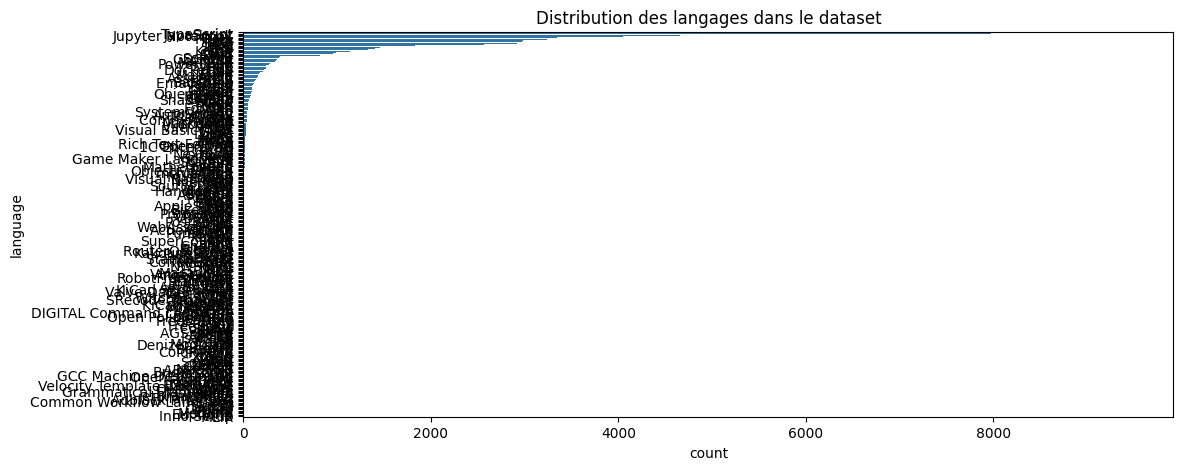

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sns.countplot(y=df["language"], order=df["language"].value_counts().index)
plt.title("Distribution des langages dans le dataset")
plt.show()

In [22]:
from train import train_log
acc = train_log(df,model_name="random_forest",epochs=10, batch_size=256)
print(f"Modèle entraîné avec une accuracy de {acc}")


              id  private   fork  forks_count  stargazers_count  \
7      927946412    False  False            1                15   
9      927907446    False  False            1                15   
11     927571539    False  False            1                15   
16     927849155    False  False            0                14   
18     927584183    False  False            0                14   
...          ...      ...    ...          ...               ...   
99992  812471022    False  False            1                 7   
99993  812731666    False  False            0                 7   
99994  812627996    False  False            1                 7   
99998  812750540    False  False            3                 7   
99999  812605455    False  False            4                 7   

       watchers_count  open_issues_count  trend_score  language  
7                  15                  0         41.5        95  
9                  15                  0         41.5       238

📈 Entraînement des epochs:   0%|          | 0/10 [00:00<?, ?it/s]


🔄 Epoch 1/10...


📈 Entraînement des epochs:  10%|█         | 1/10 [00:01<00:12,  1.40s/it]

🎯 Accuracy: 0.0802

🔄 Epoch 2/10...


...

🎯 Accuracy: 0.0995

🔄 Epoch 10/10...


📈 Entraînement des epochs: 100%|██████████| 10/10 [00:14<00:00,  1.42s/it]

🎯 Accuracy: 0.0892



2025/02/27 23:54:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'random_forest' already exists. Creating a new version of this model...
2025/02/27 23:54:45 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: random_forest, version 19
Created version '19' of model 'random_forest'.
2025/02/27 23:54:45 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: random_forest, version 20
c:\Users\TAN\Documents\Big_Data_MLOps_Github_API\src\train.py:89: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration g

✅ Modèle random_forest enregistré en version 20
Modèle random_forest version 20 mis en production sur MLflow Serving!
Nouvelle variable MODEL_NAME=random_forest enregistrée dans .env
🏃 View run caring-hare-509 at: http://127.0.0.1:8083/#/experiments/215856765795307127/runs/edbcb63046774bc48647bf7cbf3673ac
🧪 View experiment at: http://127.0.0.1:8083/#/experiments/215856765795307127
Modèle entraîné avec une accuracy de 0.08920871065114273
